<a href="https://colab.research.google.com/github/gilIolgenblum/ProteinCrowding/blob/main/tutorials/06_exporting_results_and_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exporting Results and Publication Figures

## Goal
In this final tutorial, you will learn how to extract the underlying thermodynamic arrays from the model objects and export them for external plotting software (like Origin or GraphPad Prism).
You will also learn how to tweak the `matplotlib` properties of the `BinaryPlotter` and `TernaryPlotter` for manuscript-quality figures.

## Setup

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/ProteinCrowding.git
    # Change the working directory to the repository root
    os.chdir('/content/ProteinCrowding')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/ProteinCrowding/src')

In [2]:
import crowding as cr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Module imported successfully: {cr.__name__}")

Module imported successfully: crowding


## Exporting Data Arrays
The model class structures keep all thermodynamic outputs stored as numpy arrays. For a binary model, these are 1D arrays. For a ternary model, these are 2D arrays.

Let's run a quick binary simulation to generate some data.

In [3]:
model = cr.CrowdingModel(
    protein=cr.Protein(SASA=1800.0),
    cosolute=cr.Cosolute(nu=2.479, chi=0.610, chiTS=-3.650),
    eps=-0.5,
    epsTS=0.0,
    phiC_max=0.1,
    dphiC=0.005,
    T=298.15
)
model.solve_equil()

### Method 1: Using `to_pandas()`
The easiest way is to let the model generate a DataFrame for you.

In [4]:
# This method populates the model.results attribute
model.to_pandas()
df = model.results

display(df.head())

# To export this dataframe:
# df.to_csv("my_binary_data.csv", index=False)

,phiC,phiCsurf,phiS,phiSsurf,molar,molal,osm,gamma_per_vol,gamma,gammaC_per_vol,...,ddA_chi_kJ,ddA_eps_kJ,ddA_kJ,ddE_chi_kJ,ddE_eps_kJ,ddE_kJ,TddS_nu_kJ,TddS_chi_kJ,TddS_eps_kJ,TddS_kJ
0,0.0001,0.000217,0.9999,0.999783,0.002241,0.002241,0.002241,1.172662,295.885342,-0.000047,...,0.000005,0.050203,0.029586,-0.000026,0.050203,0.050177,0.020622,-0.000031,0.0,0.020591
1,0.0051,0.011088,0.9949,0.988912,0.114293,0.114879,0.114137,1.174115,296.251868,-0.002428,...,0.013680,2.562079,1.510156,-0.068176,2.562079,2.493903,1.065603,-0.081856,0.0,0.983747
2,0.0101,0.021968,0.9899,0.978032,0.226346,0.228655,0.225742,1.175067,296.492128,-0.004836,...,0.053739,5.076143,2.993004,-0.267816,5.076143,4.808327,2.136878,-0.321556,0.0,1.815323
3,0.0151,0.032850,0.9849,0.967150,0.338398,0.343586,0.337069,1.175499,296.601153,-0.007270,...,0.120205,7.590593,4.477802,-0.599056,7.590593,6.991537,3.232997,-0.719261,0.0,2.513735
4,0.0201,0.043725,0.9799,0.956275,0.450450,0.459690,0.448134,1.175393,296.574375,-0.009726,...,0.212953,10.103542,5.964191,-1.061273,10.103542,9.042268,4.352303,-1.274226,0.0,3.078077


### Method 2: Manual Extraction
If you only need specific arrays (e.g., just the volume fractions and the Free Energy), you can extract them directly.
Remember that the model operates natively in Volume Fraction ($\phi$). To get Molal or Molar, you must extract `model.molal` or `model.molar` respectively.

In [5]:
custom_df = pd.DataFrame({
    "phi": model.phiC,
    "molal": model.molal,
    "dG_kJ": model.ddA_kj,
    "dG_kcal": model.ddA_kj / 4.184
})

display(custom_df.head())

,phi,molal,dG_kJ,dG_kcal
0,0.0001,0.002241,0.029586,0.007071
1,0.0051,0.114879,1.510156,0.360936
2,0.0101,0.228655,2.993004,0.715345
3,0.0151,0.343586,4.477802,1.070220
4,0.0201,0.459690,5.964191,1.425476


## Customizing Built-In Plots
The `cr.plotting` classes use `matplotlib` under the hood. They typically return a `matplotlib.figure.Figure` object and access the current axes (`plt.gca()`), allowing you to easily tweak labels, fonts, and limits after calling the plot function.

### Method 1: Manual Edit of Plot properties:
Use plt.rc_context to localy set the figure and font sizes

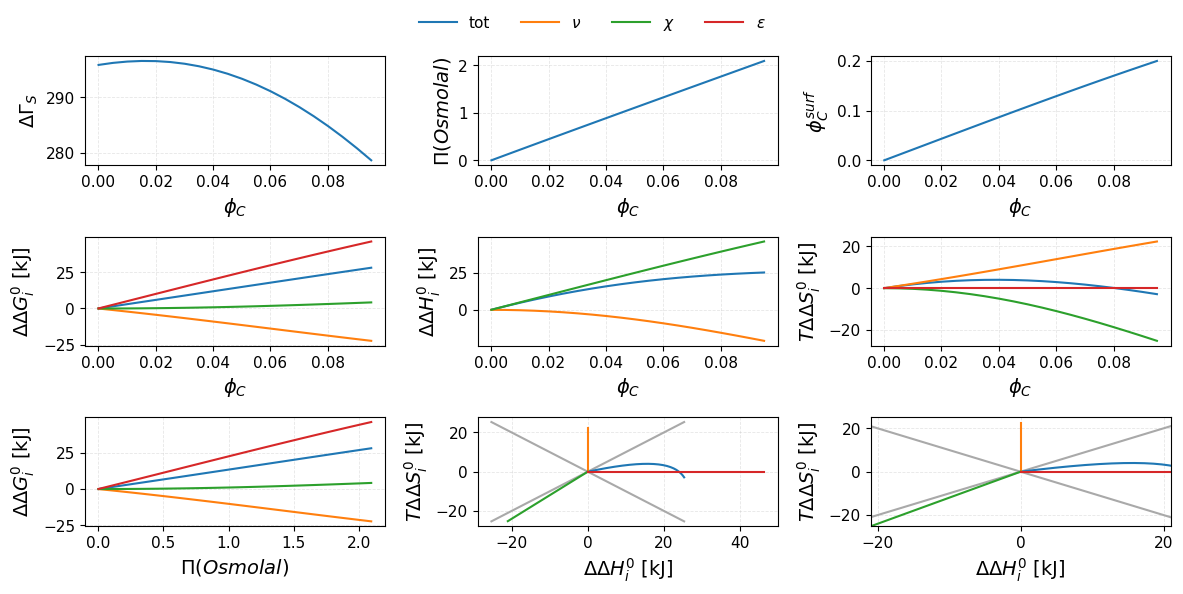

In [26]:
from cr.plotting import BinaryPlotter
import matplotlib.pyplot as plt
import warnings

plotter = BinaryPlotter(model)

with plt.rc_context({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 20,
}):

    fig = plotter.plot_results()
    fig.set_size_inches((12, 6))

    axes = fig.axes

    # Store handles/labels from one of BinaryPlotter's existing legends
    shared_handles = None
    shared_labels = None

    for ax in axes:

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.6,
            alpha=0.3
        )

        # Get the legend already created by BinaryPlotter
        legend = ax.get_legend()

        if legend is not None:

            # Get legend labels
            labels = [
                text.get_text()
                for text in legend.get_texts()
            ]

            # Get legend handles
            handles = getattr(
                legend,
                "legend_handles",
                None
            )

            # Compatibility with older Matplotlib versions
            if handles is None:
                handles = getattr(
                    legend,
                    "legendHandles",
                    []
                )

            # Save the first useful legend
            if shared_handles is None and len(handles) > 0:
                shared_handles = handles
                shared_labels = labels

            # Remove subplot legend
            legend.remove()

    # Add one shared legend
    if shared_handles is not None:

        fig.legend(
            handles=shared_handles,
            labels=shared_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.00),
            ncol=4,
            frameon=False,
            handlelength=2.5,
            columnspacing=2.0,
        )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        plt.tight_layout(
            rect=[0, 0, 1, 0.94]
        )

    plt.show()

### Method 2: Functionalized Styling


In [30]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D


def style_binary_plot(
    fig,
    figsize=(12, 6.5),
    colors=None,
    shared_legend=True,
    total_linewidth=2.7,
    component_linewidth=2.0,
    grid=True,
    debug=False,
):
    """
    Apply publication-style formatting to a BinaryPlotter figure.

    The function determines the physical identity of each curve
    (tot, ν, χ, ε) from the legends originally created by BinaryPlotter.
    This works even when the Line2D objects themselves have labels such
    as '_child0' rather than meaningful labels.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure returned by BinaryPlotter.plot_results().

    figsize : tuple
        Figure size in inches.

    colors : dict, optional
        Colors for the different contributions.

    shared_legend : bool
        Replace individual subplot legends with one figure-level legend.

    total_linewidth : float
        Width of the total curve.

    component_linewidth : float
        Width of ν, χ, and ε curves.

    grid : bool
        Display a light major grid.

    debug : bool
        Print the inferred mapping between original colors and quantities.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Styled figure.
    """

    if colors is None:
        colors = {
            "tot": "#5C9EAD",
            "ν":   "#326273",
            "χ":   "#EEEEEE",
            "ε":   "#E39774",
        }

    legend_order = ["tot", "ν", "χ", "ε"]

    # LaTeX-friendly labels for the new shared legend
    legend_display = {
        "tot": "tot",
        "ν": r"$\nu$",
        "χ": r"$\chi$",
        "ε": r"$\epsilon$",
    }

    # ------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------

    def clean_label(label):
        """Convert possible LaTeX labels to canonical names."""

        if not label:
            return label

        return (
            str(label)
            .replace("$", "")
            .replace("\\nu", "ν")
            .replace("\\chi", "χ")
            .replace("\\epsilon", "ε")
            .replace("\\varepsilon", "ε")
            .strip()
        )

    def normalize_color(color):
        """Convert any Matplotlib color representation to RGBA."""
        try:
            return tuple(round(x, 6) for x in to_rgba(color))
        except (ValueError, TypeError):
            return None

    fig.set_size_inches(figsize)

    # ============================================================
    # FIRST PASS
    #
    # Learn BinaryPlotter's original mapping:
    #
    #     blue   -> tot
    #     orange -> ν
    #     green  -> χ
    #     red    -> ε
    #
    # We obtain this from its existing legends.
    # ============================================================

    original_color_to_quantity = {}

    for ax in fig.axes:

        legend = ax.get_legend()

        if legend is None:
            continue

        # Legend text
        legend_labels = [
            clean_label(text.get_text())
            for text in legend.get_texts()
        ]

        # Matplotlib version compatibility
        handles = getattr(legend, "legend_handles", None)

        if handles is None:
            handles = getattr(legend, "legendHandles", [])

        for handle, label in zip(handles, legend_labels):

            if label not in colors:
                continue

            if hasattr(handle, "get_color"):

                original_color = normalize_color(handle.get_color())

                if original_color is not None:
                    original_color_to_quantity[original_color] = label

    if debug:
        print("Color mapping inferred from BinaryPlotter:")

        for color, quantity in original_color_to_quantity.items():
            print(f"  {color} -> {quantity}")

    # ============================================================
    # SECOND PASS
    #
    # Style axes and recolor lines.
    # ============================================================

    for ax in fig.axes:

        # --------------------------------------------------------
        # Axes
        # --------------------------------------------------------

        ax.minorticks_on()

        ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            top=False,
            right=False,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_linewidth(1.1)
        ax.spines["bottom"].set_linewidth(1.1)

        # --------------------------------------------------------
        # Grid
        # --------------------------------------------------------

        if grid:
            ax.grid(
                True,
                which="major",
                linestyle="--",
                linewidth=0.5,
                alpha=0.20,
            )
        else:
            ax.grid(False)

        # --------------------------------------------------------
        # Lines
        # --------------------------------------------------------

        for line in ax.get_lines():

            # First try the actual Line2D label
            quantity = clean_label(line.get_label())

            # If BinaryPlotter used generic labels such as "_child0",
            # identify the curve through its original color.
            if quantity not in colors:

                original_color = normalize_color(line.get_color())

                quantity = original_color_to_quantity.get(
                    original_color
                )

            # Leave auxiliary lines unchanged
            if quantity not in colors:
                continue

            # Recolor
            line.set_color(colors[quantity])

            # Styling hierarchy
            if quantity == "tot":
                line.set_linewidth(total_linewidth)
                line.set_zorder(10)

            else:
                line.set_linewidth(component_linewidth)

        # --------------------------------------------------------
        # Remove BinaryPlotter's original legends
        # --------------------------------------------------------

        if shared_legend:

            legend = ax.get_legend()

            if legend is not None:
                legend.remove()

    # ============================================================
    # SHARED LEGEND
    # ============================================================

    if shared_legend:

        # Build clean legend handles ourselves.
        # This avoids relying on BinaryPlotter's Line2D labels.
        handles = []

        for quantity in legend_order:

            linewidth = (
                total_linewidth
                if quantity == "tot"
                else component_linewidth
            )

            handles.append(
                Line2D(
                    [0],
                    [0],
                    color=colors[quantity],
                    linewidth=linewidth,
                    label=legend_display[quantity],
                )
            )

        fig.legend(
            handles=handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.00),
            ncol=4,
            frameon=False,
            handlelength=2.5,
            columnspacing=2.0,
        )

        # Leave room at the top for shared legend
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            fig.tight_layout(
                rect=[0, 0, 1, 0.94],
                w_pad=2.0,
                h_pad=1.8,
            )

    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            fig.tight_layout(
                w_pad=2.0,
                h_pad=1.8,
            )

    return fig

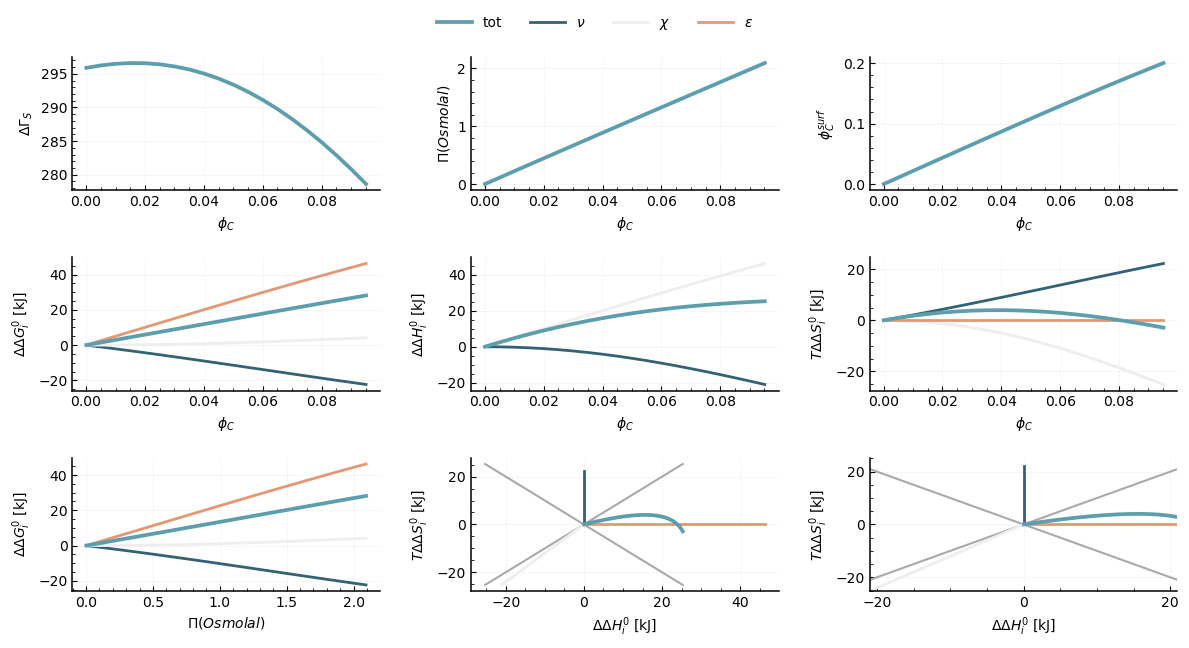

In [31]:
plotter = BinaryPlotter(model)

fig = plotter.plot_results()

fig = style_binary_plot(fig)

plt.show()

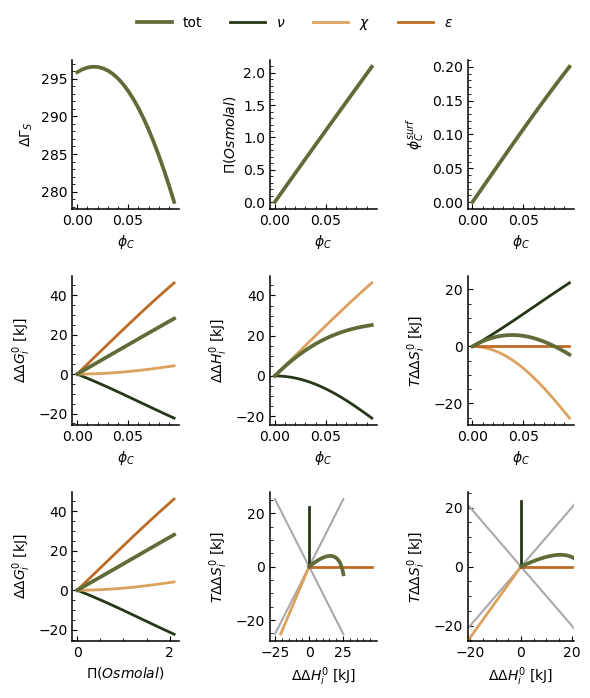

In [32]:
plotter = BinaryPlotter(model)

fig = plotter.plot_results()

fig = style_binary_plot(fig,
    figsize=(6, 7),
    colors= {
            "tot": "#606c38",
            "ν":   "#283618",
            "χ":   "#dda15e",
            "ε":   "#bc6c25",
        },
    shared_legend=True,
    grid=False)

plt.show()

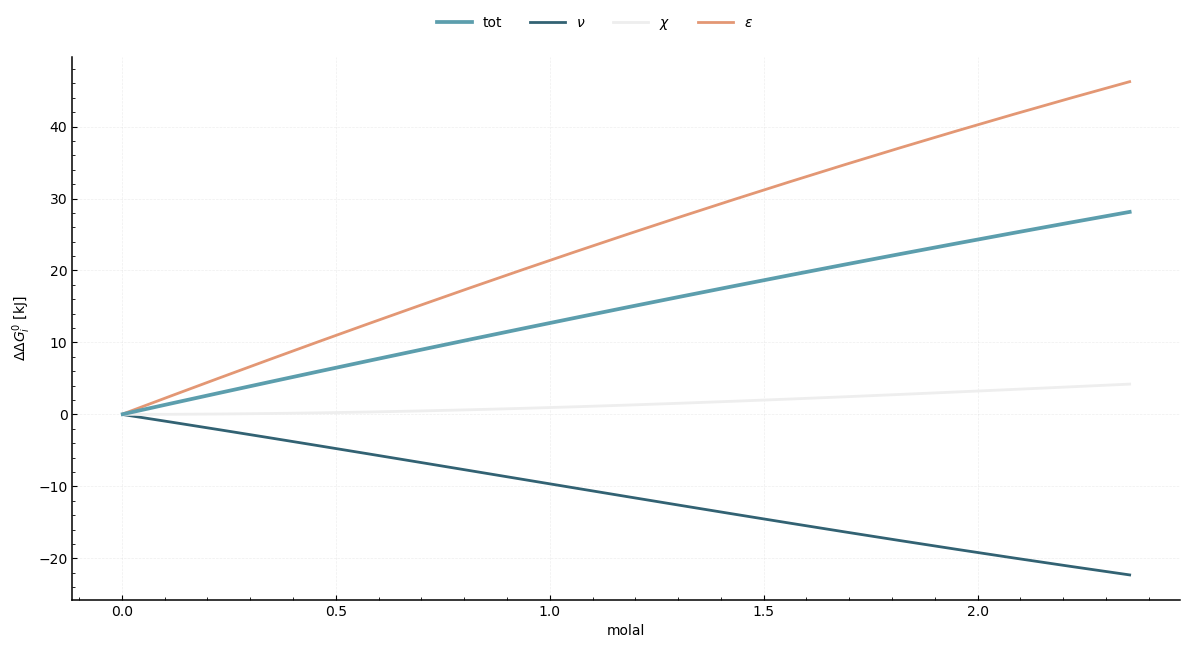

In [33]:
plotter = BinaryPlotter(model)

fig = plotter.plot_ddG(concentration_type='molal')

fig = style_binary_plot(fig)

plt.show()

## Conclusion
Congratulations! You've reached the end of the `ProteinCrowding` tutorials.

You can now:
- Run binary and ternary simulations.
- Fit complex soft interaction parameters to empirical data.
- Analyze the physical drivers behind protein stabilization and destabilization.
- Export your results and figures for your manuscripts.